I initially created my gradients, and then did the study. Problem:
- The separate sum of the components is not equal to a histogram with all components turned on.
My idea: I create gradients for the total, and use them to calculate the off baseline values for each component. I don't think this works.

I retried. Create gradients using all components (also prompt!). And just look at the total, while varying the detector systematics.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator
import os
import numpy as np
from copy import deepcopy

In [5]:
import NNMFit
from NNMFit.utilities.readout_graphs import HistogramGraph
from NNMFit.core.analysis_config import AnalysisConfig

In [6]:
import sys
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks")
# from plot_utils import plot_histogram, plot_histogram_astro_flavor, plot_histogram_astro_newflavor
from plot_utils import plot_histogram

from utils import *

In [7]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/bin_migration_overlap_dortmund/table_overlap_BPL"
os.system(f"mkdir -p {plotting_path}")

0

In [8]:
def check_total( event_rate_dict, tolerance=0.01 ):
    total = 0
    for component in [r"Conventional $\nu$",r"Prompt $\nu$",r"Atmospherc $\mu$",r"Astro $\nu$"]:
        result = event_rate_dict[component]
        total += result["rate"]
    all_rate = event_rate_dict["All"]["rate"]
    rel_diff = abs(total - all_rate) / abs(all_rate)
    print(
        f"sum = {total:.6f}, "
        f"all = {all_rate:.6f}, "
        f"relative difference = {100*rel_diff:.3f}%"
    )
    return rel_diff < tolerance
        

First load the configs

In [9]:
input_variables_base = {
    r"All" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 1, "muongun_norm" : 1},
    r"Conventional $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0},
    r"Prompt $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0},
    r"Atmospherc $\mu$" : {"total_astro_norm" : 0.0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1},
    r"Astro $\nu$" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_e$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\mu$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\tau$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
}

In [10]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"

config_hdls = {}
hist_graph_hdls = {}
detector_configs = {}

for name, config, config_sys in zip(["clean_gf", "clean_hese", "overlap"],
                                    ["globalfit_hese_clean_globalfit_dortmund", "globalfit_hese_clean_hese_dortmund", "globalfit_hese_overlap_dortmund"],
                                    ["Snowstorm_Gradients_HESE_Globalfit_clean_gf_dortmund", "Snowstorm_Gradients_HESE_Globalfit_clean_hese_dortmund", "Snowstorm_Gradients_HESE_Globalfit_overlap_dortmund"]):

    print(10*"-", name)

    config_hdls[name] = AnalysisConfig.from_configs(
            main_config_file=f"{configs_dir}/main.cfg",
            analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/globalfit_hese/globalfit_double_no_hybrid_hese_BPL_3flavor.yaml",
            config_dir=configs_dir,
            override_dict=None,
            override_config_files=[f"override/systematics/overlap_dortmund/{config_sys}.cfg",
                                   f"override/datasets_GP_globalfit/dortmund/{config}.cfg",
                                   f"override/binning/hese/10bdtprod_threshold_0.122.cfg"],
            override_components_files=["override/components/astro_BPL_3flavor_no_inel.yaml",
                                    "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
            override_parameters_files=None)
    hist_graph_hdls[name] = HistogramGraph(config_hdls[name])
    detector_configs[name] = config_hdls[name].get_det_configs()


---------- clean_gf
---------- clean_hese
---------- overlap


Check the rates

In [11]:
input_variables_base = {
    r"All" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 1, "muongun_norm" : 1},
    r"Conventional $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0},
    r"Prompt $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0},
    r"Atmospherc $\mu$" : {"total_astro_norm" : 0.0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1},
    r"Astro $\nu$" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_e$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\mu$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\tau$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
}

# Parameter names
param_names = ["dom_eff", "ice_abs", "ice_scat", "ice_holep0", "ice_holep1", "ice_crystal"]

# Default values
default_values = [1.0, 1.0, 1.0, 0.24901831812365854, -0.05678798504997925, 1.0]

# Build dict of default detector-systematics parameters
default_param_dict = dict(zip(param_names, default_values))

input_variables_nominal_syst = deepcopy(input_variables_base)

for component, param_dict in input_variables_nominal_syst.items():
    param_dict.update(default_param_dict)

Rates match when creating new config hdls, and not setting any of the detector systematics. 
Differences for the tracks though?!

In [12]:
rates = {}

for name in ["clean_gf", "clean_hese", "overlap"]:

    print(10*"-", name)

    rates[name] = {}

    for det_config in detector_configs[name]: 

        print(det_config)

        rates[name][det_config] = get_event_rates(hist_graph_hdl=hist_graph_hdls[name], det_config=det_config, input_variables = input_variables_base)

        # check total
        if not check_total( rates[name][det_config] ):
            print("All is not sum of components", name, det_config)
            print(input_variables_base)
            print(rates[name][det_config])

---------- clean_gf
IC86_pass2_SnowStorm_v2_tracks
sum = 707236.876865, all = 703822.375370, relative difference = 0.485%
IC86_pass2_SnowStorm_v2_cscd_muon
sum = 27203.644403, all = 27203.644403, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade
sum = 11830.532162, all = 11830.532162, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double
sum = 1.563646, all = 1.563646, relative difference = 0.000%
IC86_pass2_SnowStorm_FTP_HESE_Cascades
sum = 63.355848, all = 63.355848, relative difference = 0.000%
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 4.863072, all = 4.863072, relative difference = 0.000%
IC86_pass2_SnowStorm_FTP_HESE_Tracks
sum = 18.012574, all = 18.012574, relative difference = 0.000%
---------- clean_hese
IC86_pass2_SnowStorm_v2_tracks
sum = 707244.319428, all = 703829.817934, relative difference = 0.485%
IC86_pass2_SnowStorm_v2_cscd_muon
sum = 27203.650025, all = 27203.650025, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_

Now I do the same but I set the detector systematics to the nominal. Seems to be fine as well!

In [13]:
det_configs = ["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades","IC86_pass2_SnowStorm_v2_cscd_cascade_double"]

rates = {}

for name in ["clean_gf", "clean_hese", "overlap"]:

    print(10*"-", name)

    rates[name] = {}

    for det_config in det_configs:

        print(det_config)

        rates[name][det_config] = get_event_rates(hist_graph_hdl=hist_graph_hdls[name], det_config=det_config, input_variables = input_variables_nominal_syst)

        # check total
        if not check_total( rates[name][det_config] ):
            print("All is not sum of components", name, det_config)
            print(input_variables_nominal_syst)
            print(rates[name][det_config])

---------- clean_gf
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 4.863072, all = 4.863072, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double
sum = 1.563646, all = 1.563646, relative difference = 0.000%
---------- clean_hese
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 1.739307, all = 1.739307, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double
sum = 3.815492, all = 3.815492, relative difference = 0.000%
---------- overlap
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 3.123765, all = 3.123765, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double
sum = 2.251846, all = 2.251846, relative difference = 0.000%


Now I try it again, but after running some boundaries of the systematics, seems fine

In [14]:
det_configs = ["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades","IC86_pass2_SnowStorm_v2_cscd_cascade_double"]

rates = {}

for name in ["clean_gf", "clean_hese", "overlap"]:

    print(10*"-", name)

    rates[name] = {}

    for det_config in det_configs:

        print(det_config)

        rates[name][det_config] = get_event_rates(hist_graph_hdl=hist_graph_hdls[name], det_config=det_config, input_variables = input_variables_nominal_syst)

        # check total
        if not check_total( rates[name][det_config] ):
            print("All is not sum of components", name, det_config)
            print(input_variables_nominal_syst)
            print(rates[name][det_config])

---------- clean_gf
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 4.863072, all = 4.863072, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double


sum = 1.563646, all = 1.563646, relative difference = 0.000%
---------- clean_hese
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 1.739307, all = 1.739307, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double
sum = 3.815492, all = 3.815492, relative difference = 0.000%
---------- overlap
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 3.123765, all = 3.123765, relative difference = 0.000%
IC86_pass2_SnowStorm_v2_cscd_cascade_double
sum = 2.251846, all = 2.251846, relative difference = 0.000%


Now I try to set one variable off the baseline

In [15]:
input_variables_shift_syst = deepcopy(input_variables_nominal_syst)

for component, param_dict in input_variables_shift_syst.items():
    param_dict.update({"dom_eff" : 0.95})

rates = {}

for name in ["clean_gf", "clean_hese", "overlap"]:

    print(10*"-", name)

    rates[name] = {}

    for det_config in det_configs:

        print(det_config)

        rates[name][det_config] = get_event_rates(hist_graph_hdl=hist_graph_hdls[name], det_config=det_config, input_variables = input_variables_shift_syst)

        # check total
        if not check_total( rates[name][det_config] ):
            print("All is not sum of components", name, det_config)
            print(input_variables_shift_syst)
            print(rates[name][det_config])

---------- clean_gf
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 4.793554, all = 4.611428, relative difference = 3.949%
All is not sum of components clean_gf IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
{'All': {'total_astro_norm': 5.3100000000000005, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_norm': 1, 'muongun_norm': 1, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0}, 'Conventional $\\nu$': {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 0, 'conv_norm': 1, 'muongun_norm': 0, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0}, 'Prompt $\\nu$': {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_

sum = 1.785311, all = 1.632928, relative difference = 9.332%
All is not sum of components clean_hese IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
{'All': {'total_astro_norm': 5.3100000000000005, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_norm': 1, 'muongun_norm': 1, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0}, 'Conventional $\\nu$': {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 0, 'conv_norm': 1, 'muongun_norm': 0, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0}, 'Prompt $\\nu$': {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_norm': 0, 'muongun_norm': 0, 'dom_eff': 0.95, 'ice_abs': 1.0, '

Calculate the rates

In [16]:
det_configs = ["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades","IC86_pass2_SnowStorm_v2_cscd_cascade_double"]

def calculate_overlap( input_variables ):

    rates = {}

    for name in ["clean_gf", "clean_hese", "overlap"]:

        print(10*"-", name)

        rates[name] = {}

        for det_config in det_configs: 

            print(det_config)

            rates[name][det_config] = get_event_rates(hist_graph_hdl=hist_graph_hdls[name], det_config=det_config, input_variables = input_variables)

            # check total
            if not check_total( rates[name][det_config] ):
                print("All is not sum of components", name, det_config)
                for key, input_param in input_variables.items(): print(key,input_param)
                for key, rate in rates[name][det_config].items(): print(key,rate)

    overlap_percentage_hese = rates["overlap"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["All"]["rate"]/rates["clean_gf"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["All"]["rate"]
    overlap_percentage_gf = rates["overlap"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"]["All"]["rate"]/rates["clean_hese"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"]["All"]["rate"]

    tau_overlap_percentage_hese = rates["overlap"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"][r"Astro $\nu_\tau$"]["rate"]/rates["clean_gf"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"][r"Astro $\nu_\tau$"]["rate"]
    tau_overlap_percentage_gf = rates["overlap"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"][r"Astro $\nu_\tau$"]["rate"]/rates["clean_hese"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"][r"Astro $\nu_\tau$"]["rate"]

    return rates,overlap_percentage_hese,overlap_percentage_gf,tau_overlap_percentage_hese,tau_overlap_percentage_gf


In [17]:
import numpy as np
from copy import deepcopy
from utils import *

# Parameter names
param_names = ["dom_eff", "ice_abs", "ice_scat", "ice_holep0", "ice_holep1", "ice_crystal", "inel_scale"]

# Default values
default_values = [1.0, 1.0, 1.0, 0.24901831812365854, -0.05678798504997925, 1.0, 1.0]

# Ranges for each parameter
param_ranges = [
    (0.95, 1.05),           # dom_eff
    (0.9, 1.1),           # ice_abs
    (0.9, 1.1),           # ice_scat
    (-0.1, 0.5980366362473171),   # ice_holep0
    (-0.1135759700999585, 0.0),   # ice_holep1
    (0.8, 1.2),            # ice_crystal
    (0.5, 1.5),            # inel_scale
]

# Build dict of default detector-systematics parameters
default_param_dict = dict(zip(param_names, default_values))

n_points = 3  # how many points to sample in each range

for i, param in enumerate(param_names):

    print(10*"-")
    print(param)

    values = np.linspace(param_ranges[i][0],param_ranges[i][1],n_points)

    scans = []

    for value in values:

        # deep copy because nested dicts
        input_variables = deepcopy(input_variables_base)

        # add all default parameters first
        for sample_name in input_variables:

            input_variables[sample_name].update(default_param_dict)

            # vary only one parameter
            input_variables[sample_name][param] = value

        rates,overlap_percentage_hese,overlap_percentage_gf,tau_overlap_percentage_hese,tau_overlap_percentage_gf = calculate_overlap(input_variables)

        break

    break

----------
dom_eff
---------- clean_gf
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
sum = 4.793554, all = 4.611428, relative difference = 3.949%
All is not sum of components clean_gf IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades
All {'total_astro_norm': 5.3100000000000005, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_norm': 1, 'muongun_norm': 1, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0, 'inel_scale': 1.0}
Conventional $\nu$ {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 0, 'conv_norm': 1, 'muongun_norm': 0, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0, 'inel_scale': 1.0}
Prompt $\nu$ {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.444

sum = 1.706126, all = 1.583335, relative difference = 7.755%
All is not sum of components clean_gf IC86_pass2_SnowStorm_v2_cscd_cascade_double
All {'total_astro_norm': 5.3100000000000005, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_norm': 1, 'muongun_norm': 1, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0, 'inel_scale': 1.0}
Conventional $\nu$ {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 0, 'conv_norm': 1, 'muongun_norm': 0, 'dom_eff': 0.95, 'ice_abs': 1.0, 'ice_scat': 1.0, 'ice_holep0': 0.24901831812365854, 'ice_holep1': -0.05678798504997925, 'ice_crystal': 1.0, 'inel_scale': 1.0}
Prompt $\nu$ {'total_astro_norm': 0, 'gamma_1': 1.31, 'gamma_2': 2.74, 'e_break': 4.39, 'a': 0.4444444444, 'b': 0.0, 'prompt_norm': 1, 'conv_norm': 0, 'muongun_norm': 0, 'dom_eff': 0.

In [18]:
overlap_percentage_hese = rates["overlap"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["All"]["rate"]/rates["clean_gf"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["All"]["rate"]
overlap_percentage_gf = rates["overlap"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"]["All"]["rate"]/rates["clean_hese"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"]["All"]["rate"]
print(rates["overlap"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["All"]["rate"])
print(rates["clean_gf"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["All"]["rate"])
print(overlap_percentage_hese,overlap_percentage_gf)


tau_overlap_percentage_hese = rates["overlap"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"][r"Astro $\nu_\tau$"]["rate"]/rates["clean_gf"]["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"][r"Astro $\nu_\tau$"]["rate"]
tau_overlap_percentage_gf = rates["overlap"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"][r"Astro $\nu_\tau$"]["rate"]/rates["clean_hese"]["IC86_pass2_SnowStorm_v2_cscd_cascade_double"][r"Astro $\nu_\tau$"]["rate"]


print(tau_overlap_percentage_hese,tau_overlap_percentage_gf)

2.9950960088780683
4.611427786091518
0.6494942884959726 0.574479873078569
0.6873669889247165 0.5792458725011967


Overlap plots

First clean globalfit

In [19]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"
config_hdl = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/globalfit_hese/globalfit_double_no_hybrid_hese_BPL_3flavor.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_GP_globalfit.cfg",
                               "override/systematics/NoSystematics_hese.cfg",
                               "override/datasets_GP_globalfit/dortmund/globalfit_hese_clean_globalfit_dortmund.cfg",
                               "override/binning/hese/10bdtprod_threshold_0.122.cfg"],
        override_components_files=["override/components/astro_BPL_3flavor_no_inel.yaml",
                                   "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
        override_parameters_files=None)
hist_graph_hdl = HistogramGraph(config_hdl)
detector_configs = config_hdl.get_det_configs()

IC86_pass2_SnowStorm_v2_tracks


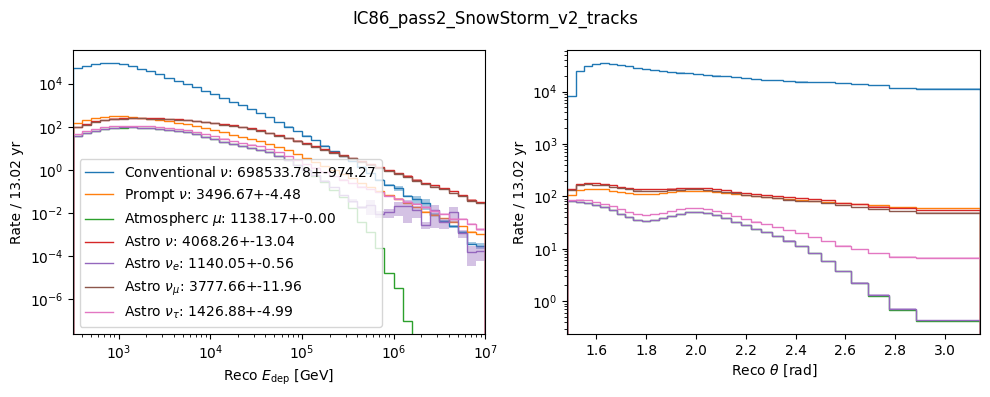

IC86_pass2_SnowStorm_v2_tracks


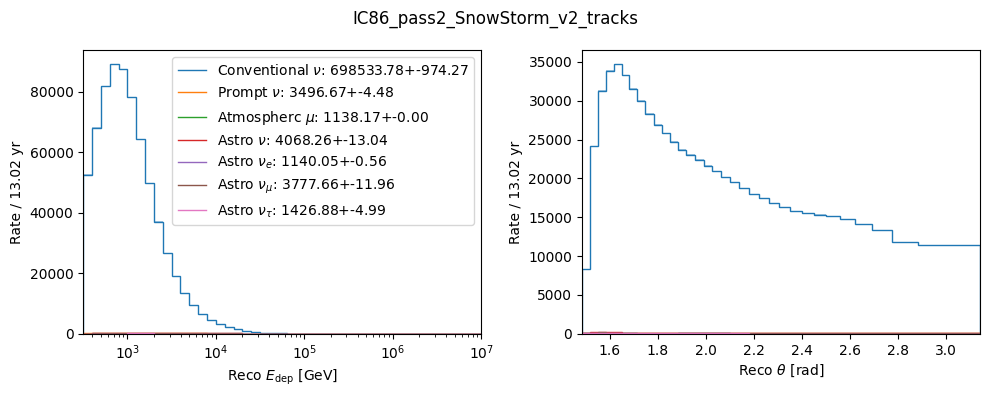

IC86_pass2_SnowStorm_v2_cscd_muon


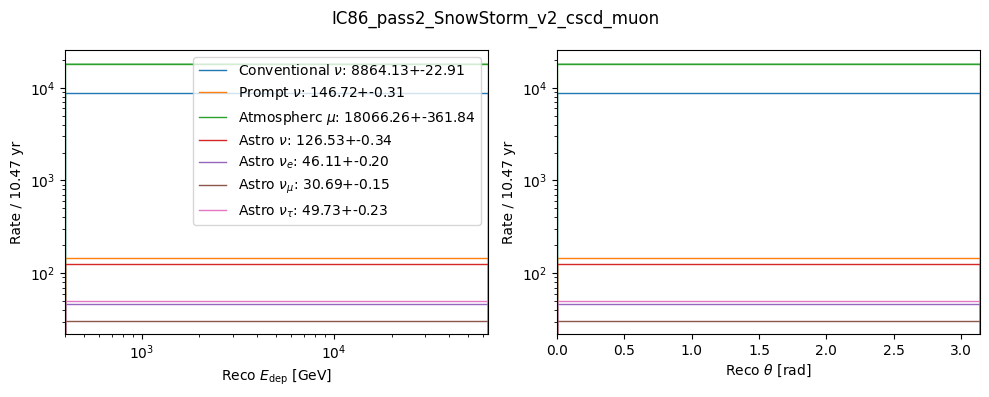

IC86_pass2_SnowStorm_v2_cscd_muon


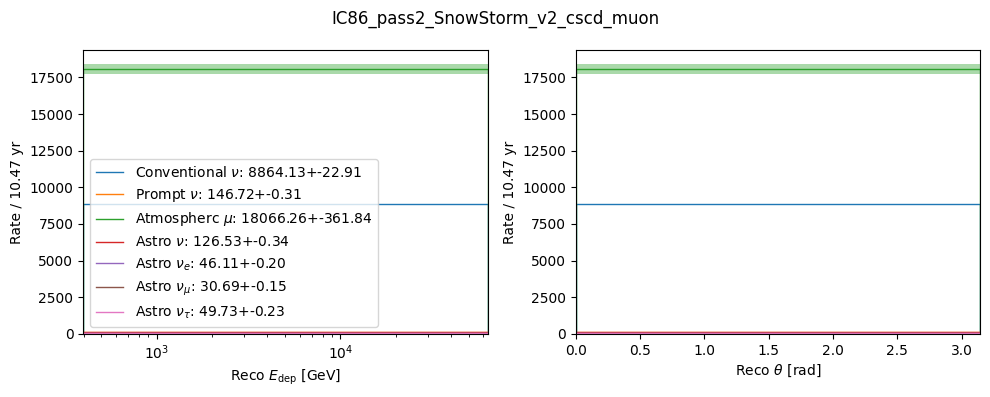

IC86_pass2_SnowStorm_v2_cscd_cascade


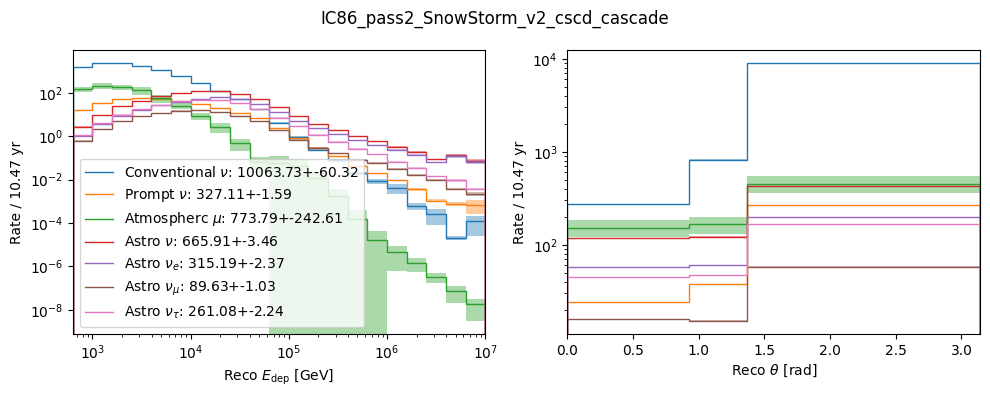

IC86_pass2_SnowStorm_v2_cscd_cascade


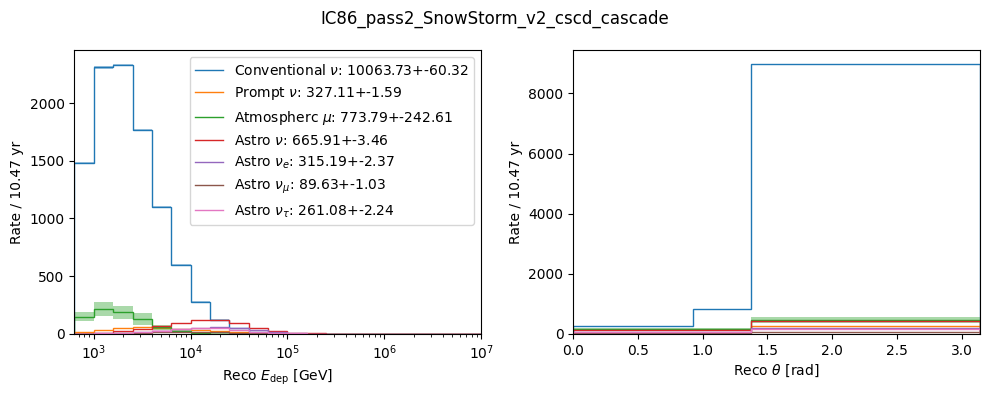

IC86_pass2_SnowStorm_v2_cscd_cascade_double


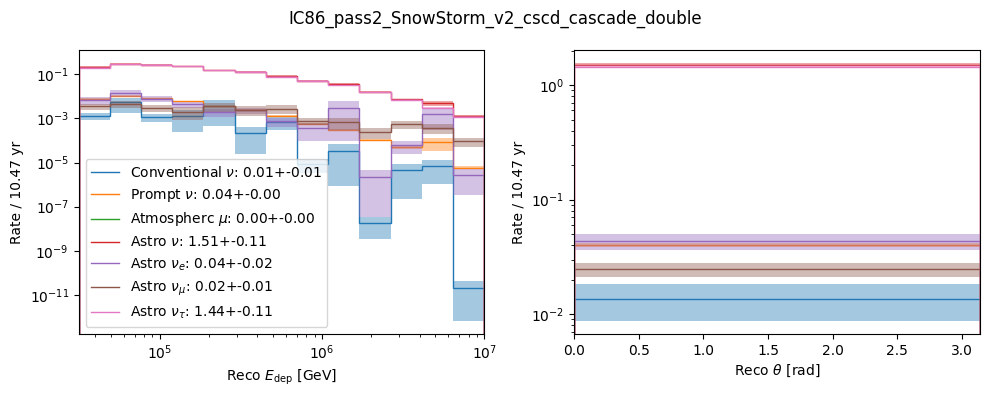

IC86_pass2_SnowStorm_v2_cscd_cascade_double


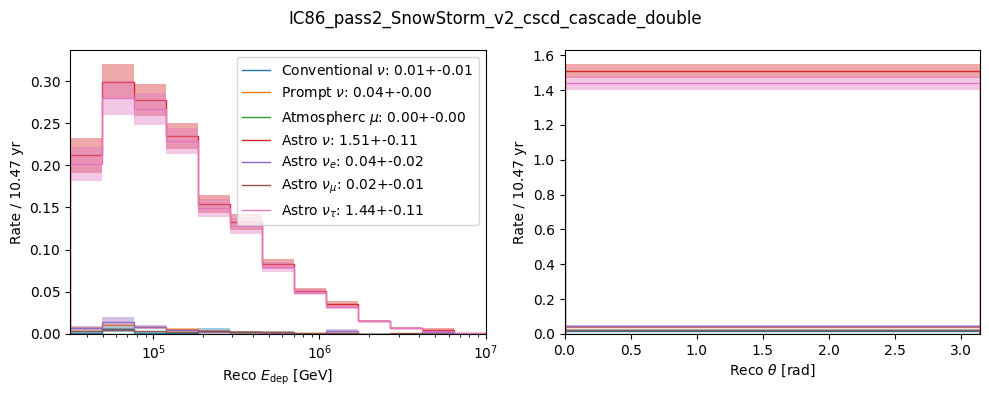

IC86_pass2_SnowStorm_FTP_HESE_Cascades


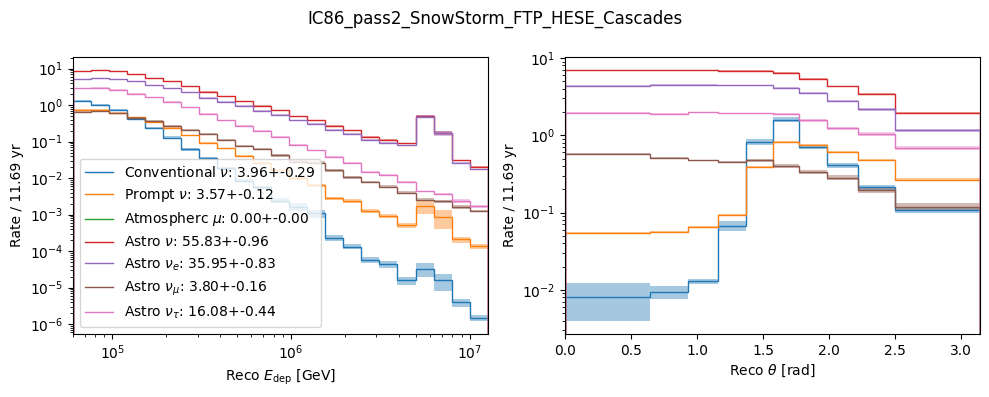

IC86_pass2_SnowStorm_FTP_HESE_Cascades


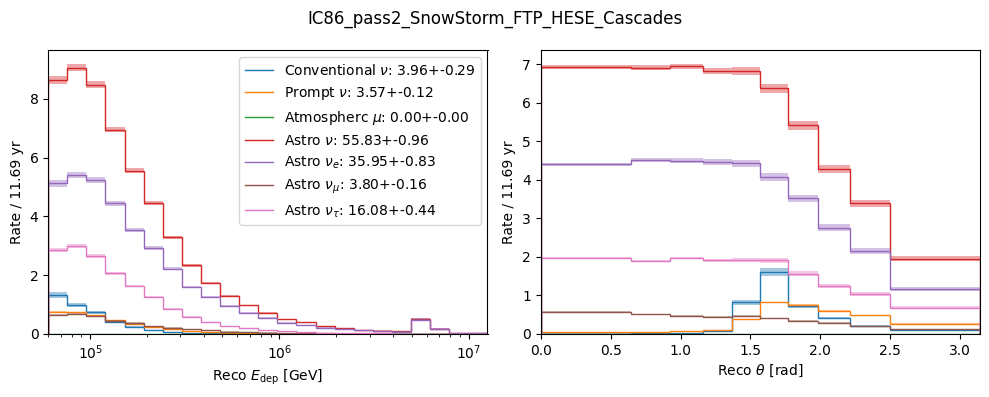

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


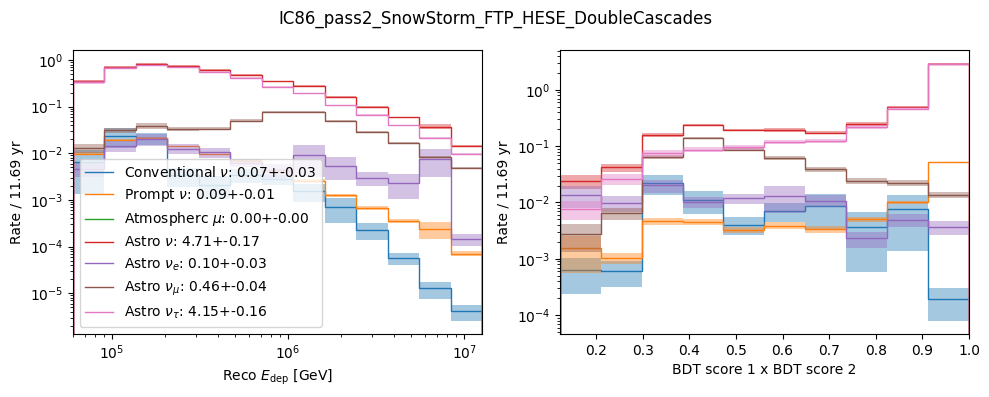

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


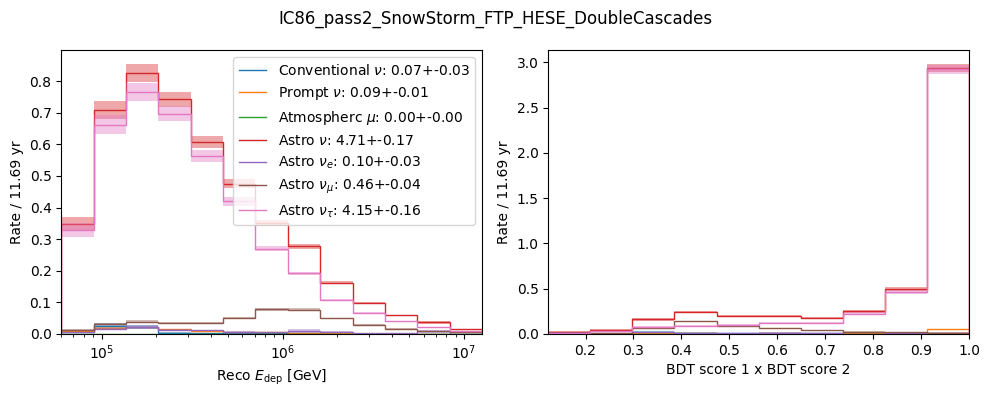

IC86_pass2_SnowStorm_FTP_HESE_Tracks


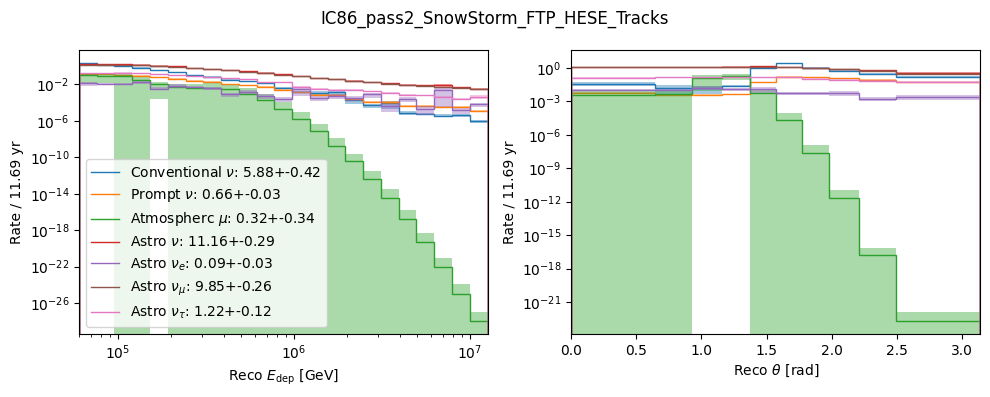

IC86_pass2_SnowStorm_FTP_HESE_Tracks


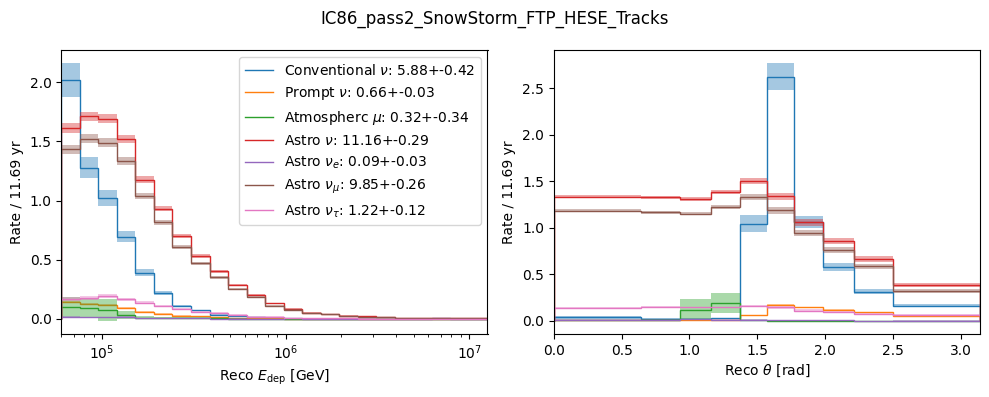

In [20]:
plotting_path_histogram = f"{plotting_path}/globalfit_hese_clean_globalfit"
os.system(f"mkdir -p {plotting_path_histogram}")

input_variables = {
    r"Conventional $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0},
    r"Prompt $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0},
    r"Atmospherc $\mu$" : {"total_astro_norm" : 0.0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1},
    r"Astro $\nu$" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_e$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\mu$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\tau$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
}

for det_config in detector_configs: 
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=True, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-True.png")
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=False, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-False.png")

Clean hese

In [21]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"
config_hdl = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/globalfit_hese/globalfit_double_no_hybrid_hese_BPL_3flavor.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_GP_globalfit.cfg",
                               "override/systematics/NoSystematics_hese.cfg",
                               "override/datasets_GP_globalfit/dortmund/globalfit_hese_clean_hese_dortmund.cfg",
                               "override/binning/hese/10bdtprod_threshold_0.122.cfg"],
        override_components_files=["override/components/astro_BPL_3flavor_no_inel.yaml",
                                   "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
        override_parameters_files=None)
hist_graph_hdl = HistogramGraph(config_hdl)
detector_configs = config_hdl.get_det_configs()

IC86_pass2_SnowStorm_v2_tracks


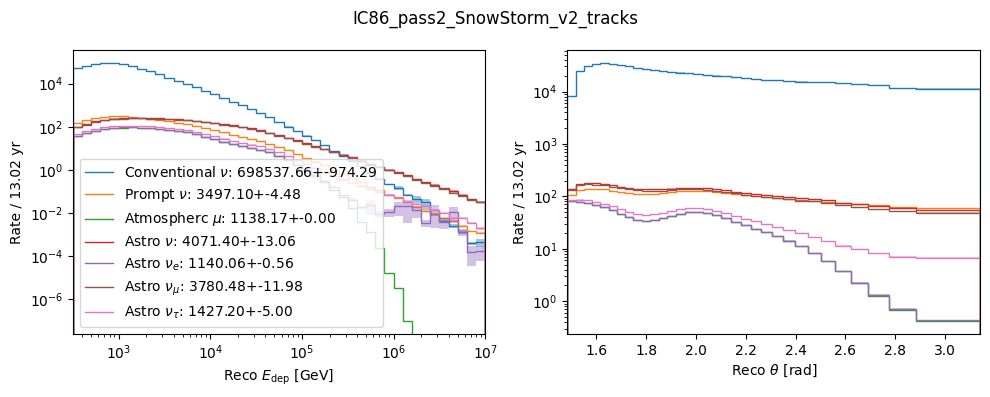

IC86_pass2_SnowStorm_v2_tracks


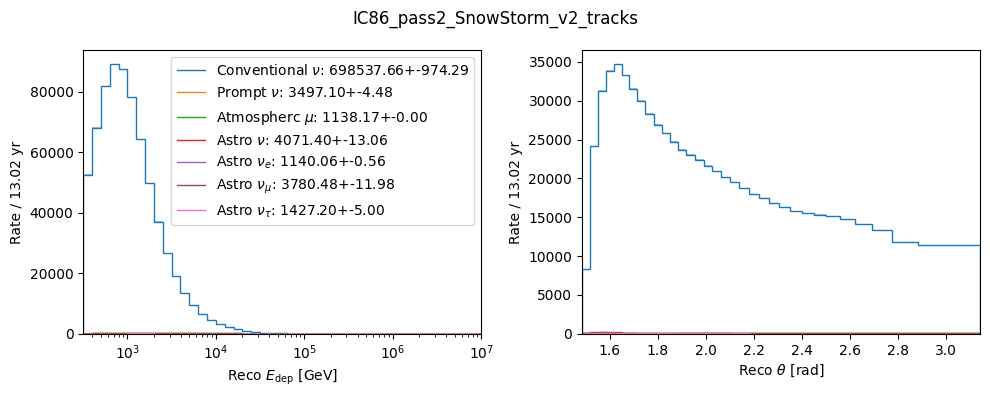

IC86_pass2_SnowStorm_v2_cscd_muon


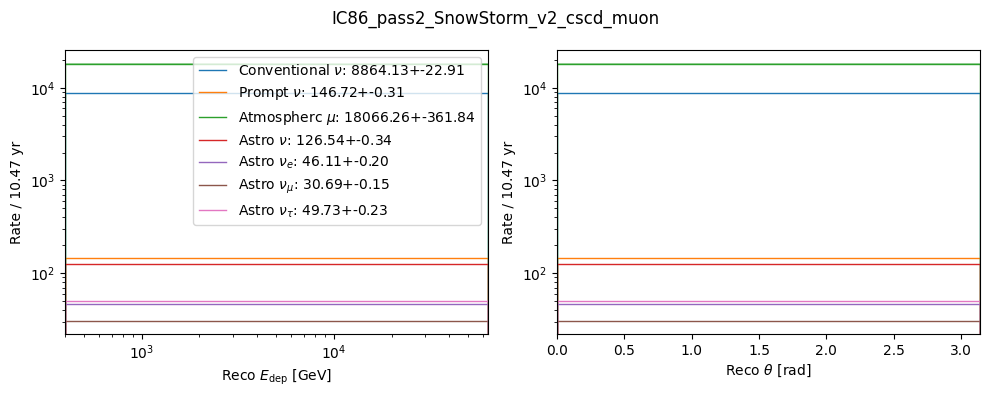

IC86_pass2_SnowStorm_v2_cscd_muon


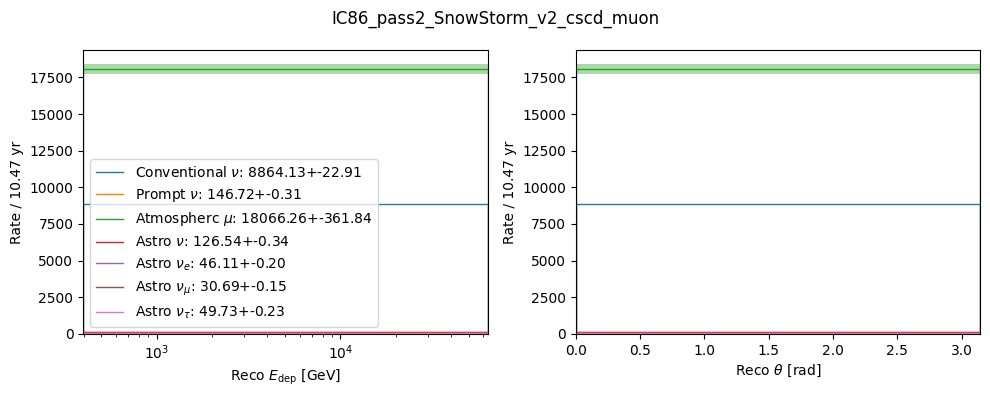

IC86_pass2_SnowStorm_v2_cscd_cascade


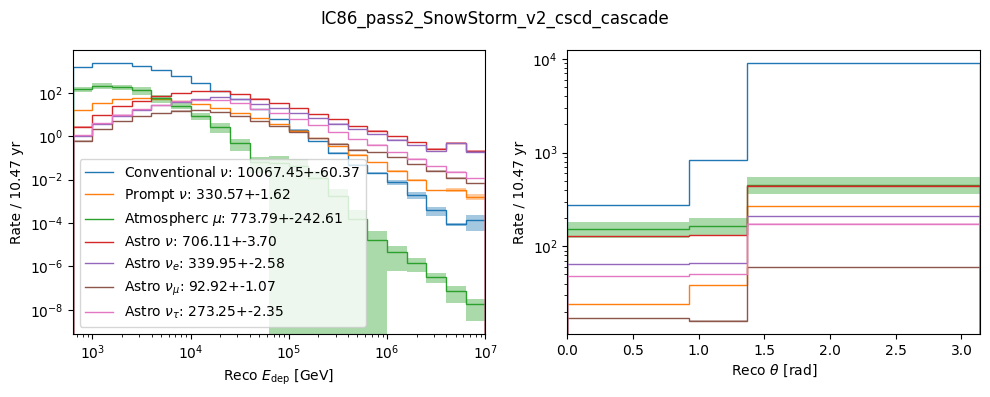

IC86_pass2_SnowStorm_v2_cscd_cascade


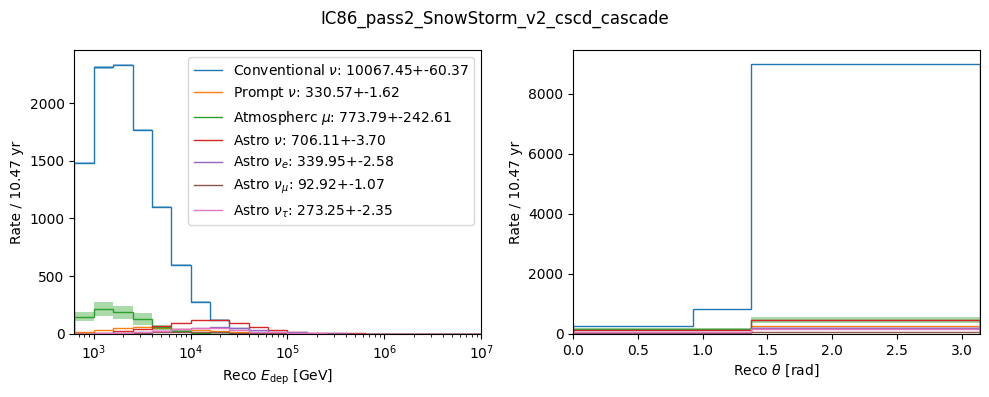

IC86_pass2_SnowStorm_v2_cscd_cascade_double


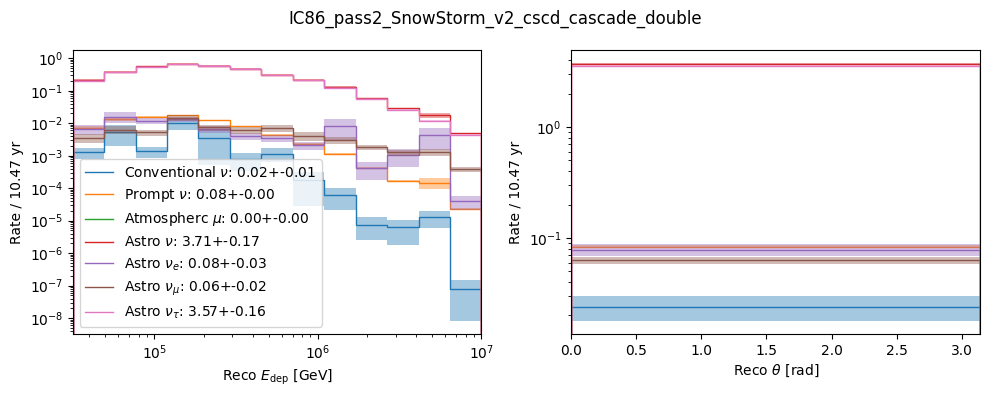

IC86_pass2_SnowStorm_v2_cscd_cascade_double


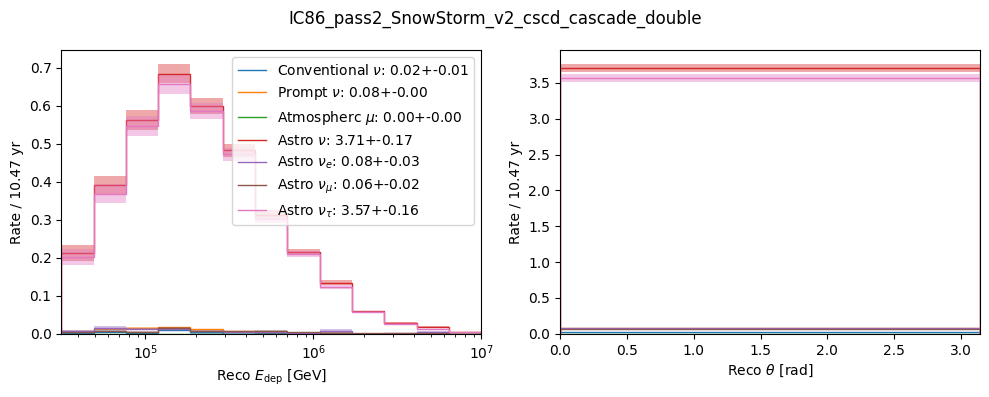

IC86_pass2_SnowStorm_FTP_HESE_Cascades


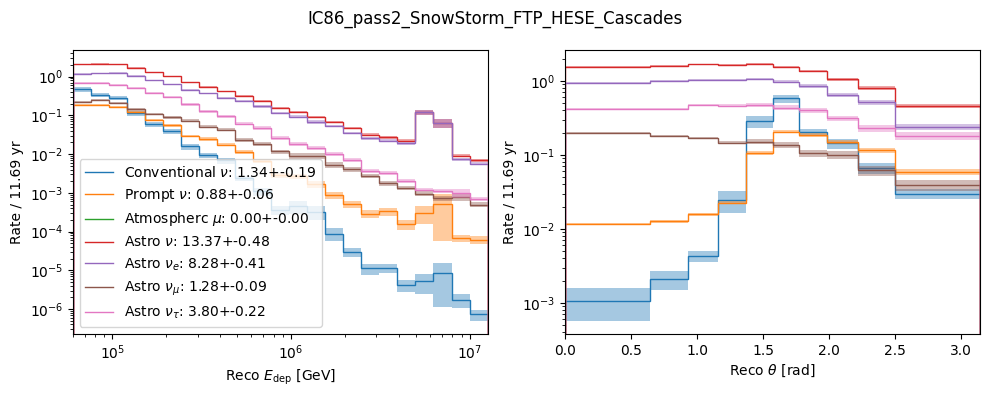

IC86_pass2_SnowStorm_FTP_HESE_Cascades


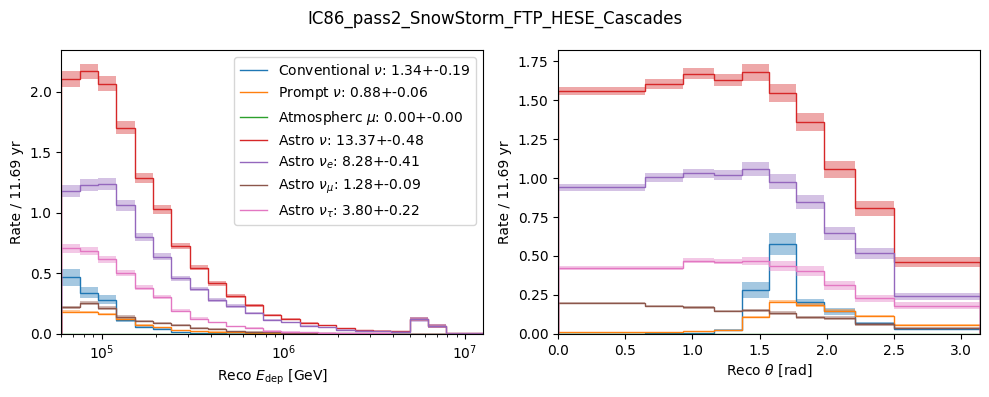

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


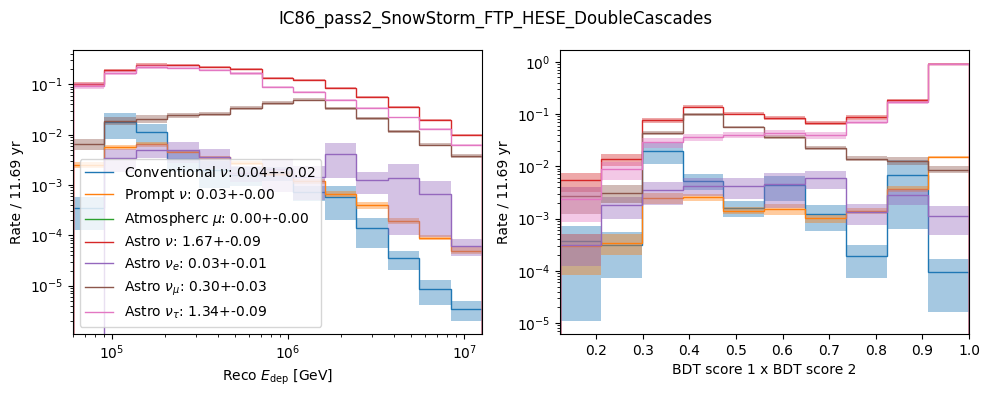

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


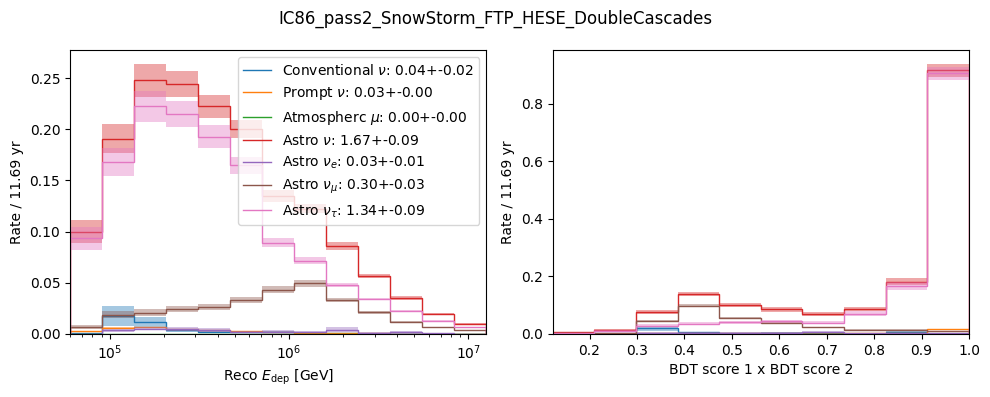

IC86_pass2_SnowStorm_FTP_HESE_Tracks


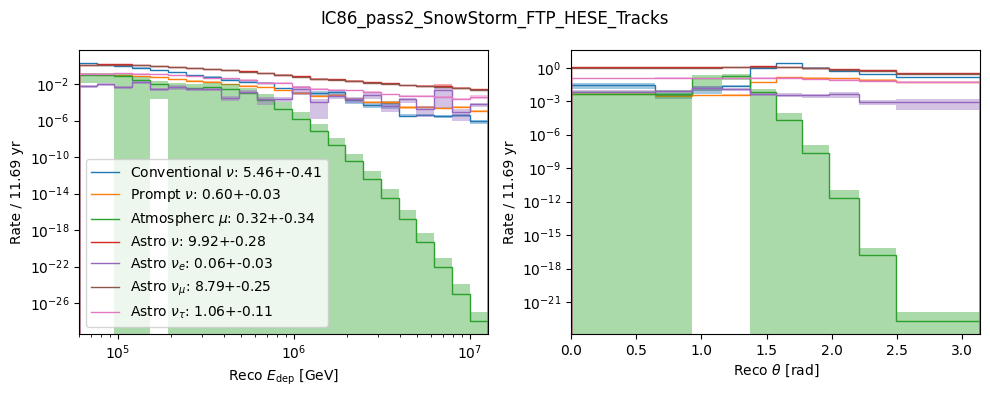

IC86_pass2_SnowStorm_FTP_HESE_Tracks


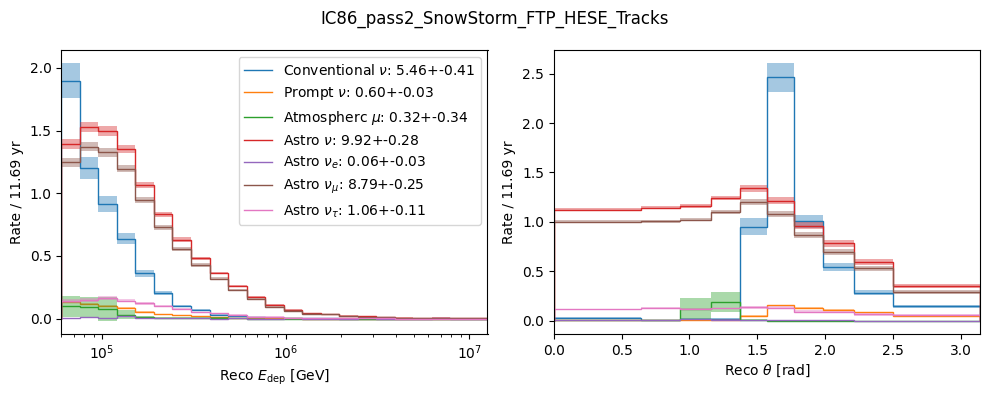

In [22]:
plotting_path_histogram = f"{plotting_path}/globalfit_hese_clean_hese"
os.system(f"mkdir -p {plotting_path_histogram}")

input_variables = {
    r"Conventional $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0},
    r"Prompt $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0},
    r"Atmospherc $\mu$" : {"total_astro_norm" : 0.0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1},
    r"Astro $\nu$" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_e$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\mu$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\tau$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
}

for det_config in detector_configs: 
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=True, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-True.png")
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=False, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-False.png")

Overlap

In [23]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"
config_hdl = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/globalfit_hese/globalfit_double_no_hybrid_hese_BPL_3flavor.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_GP_globalfit.cfg",
                               "override/systematics/NoSystematics_hese.cfg",
                               "override/datasets_GP_globalfit/dortmund/globalfit_hese_overlap_dortmund.cfg",
                               "override/binning/hese/10bdtprod_threshold_0.122.cfg"],
        override_components_files=["override/components/astro_BPL_3flavor_no_inel.yaml",
                                   "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
        override_parameters_files=None)
hist_graph_hdl = HistogramGraph(config_hdl)
detector_configs = config_hdl.get_det_configs()

IC86_pass2_SnowStorm_v2_tracks


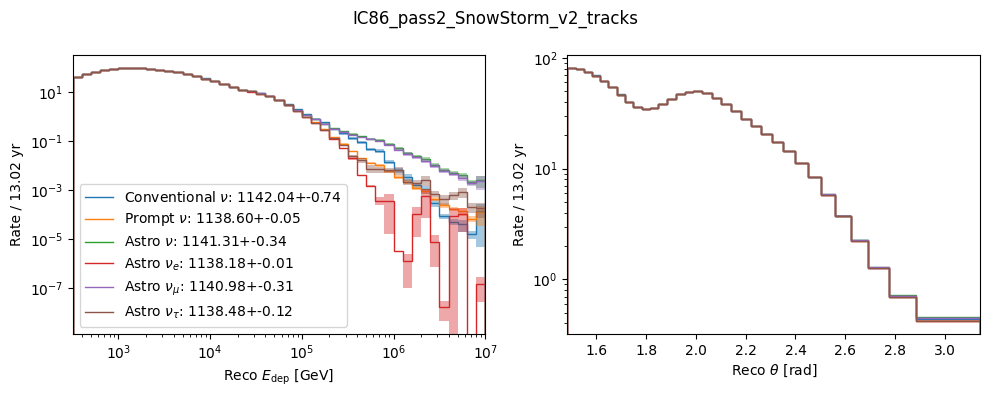

IC86_pass2_SnowStorm_v2_tracks


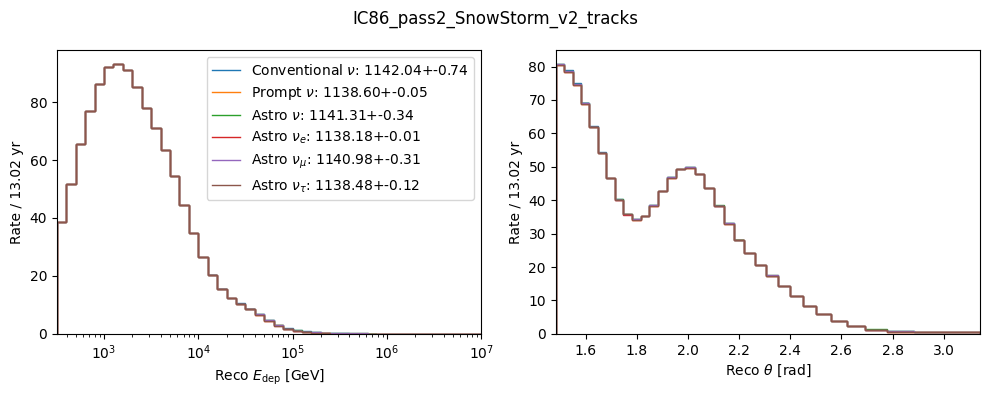

IC86_pass2_SnowStorm_v2_cscd_muon


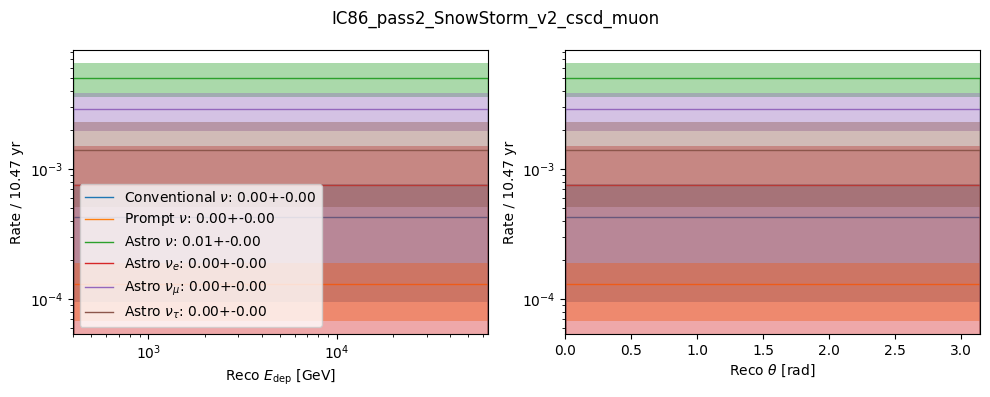

IC86_pass2_SnowStorm_v2_cscd_muon


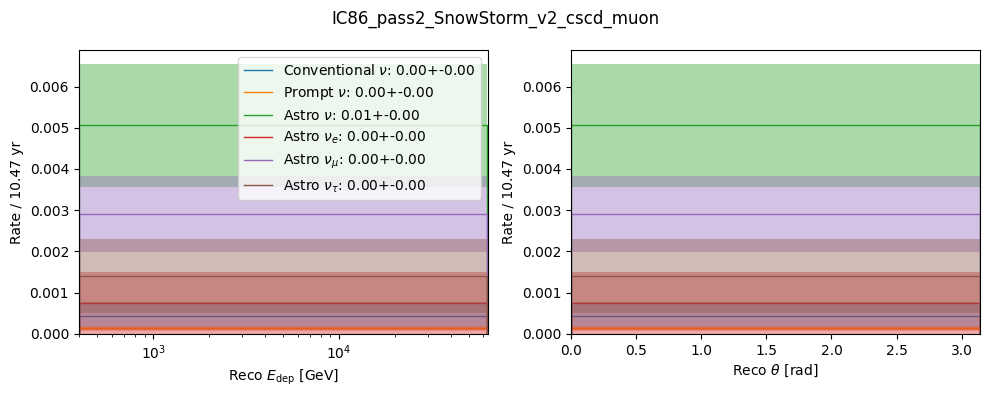

IC86_pass2_SnowStorm_v2_cscd_cascade


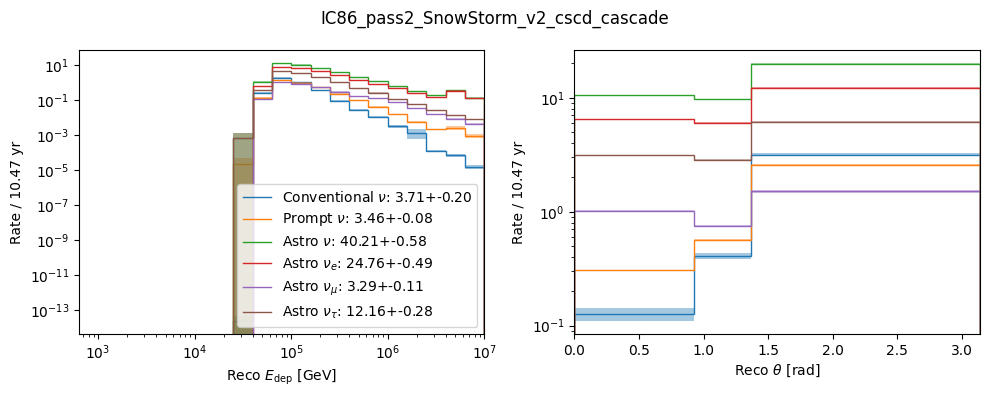

IC86_pass2_SnowStorm_v2_cscd_cascade


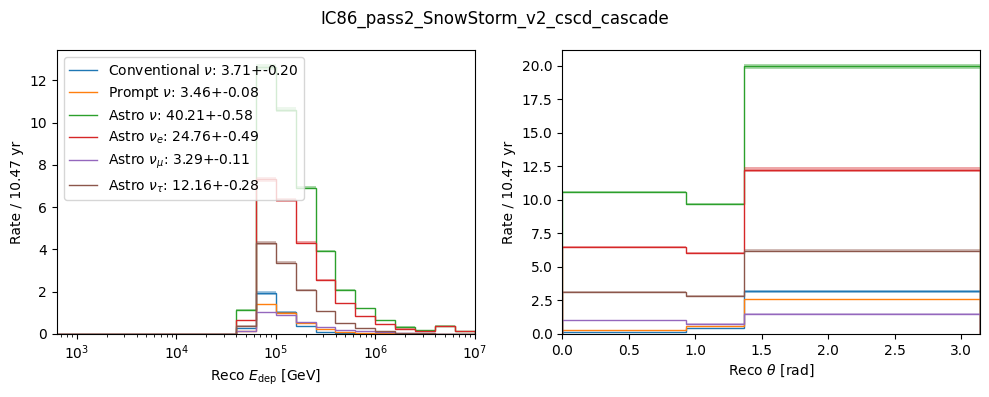

IC86_pass2_SnowStorm_v2_cscd_cascade_double


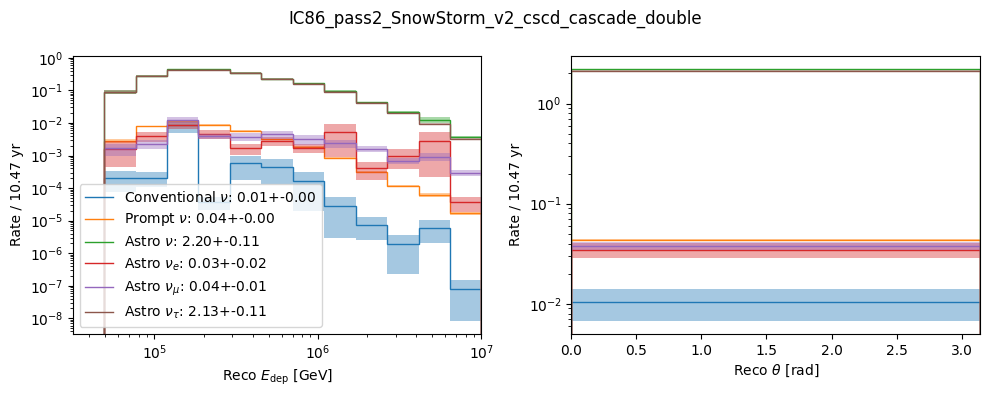

IC86_pass2_SnowStorm_v2_cscd_cascade_double


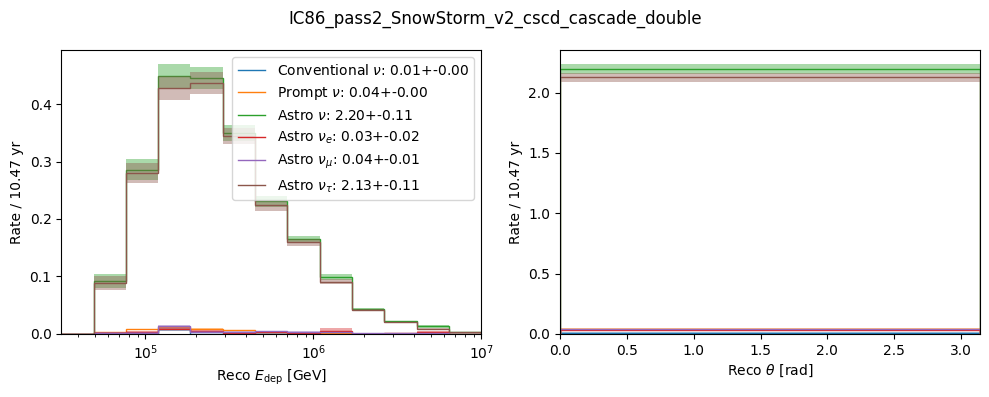

IC86_pass2_SnowStorm_FTP_HESE_Cascades


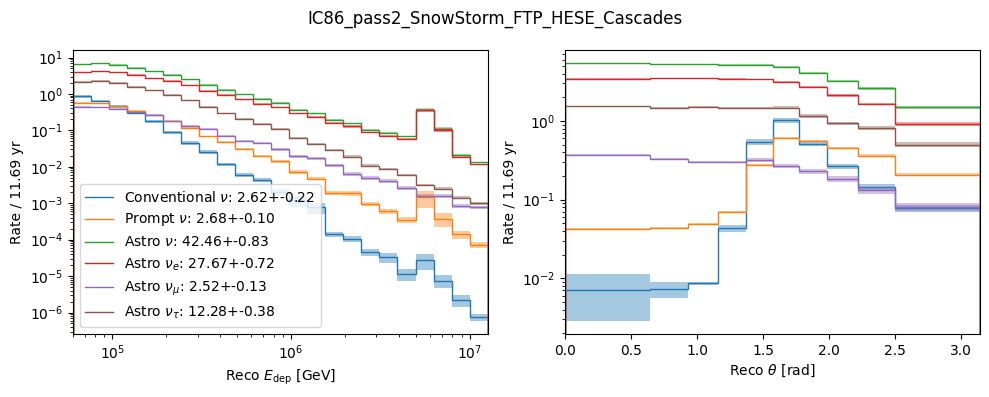

IC86_pass2_SnowStorm_FTP_HESE_Cascades


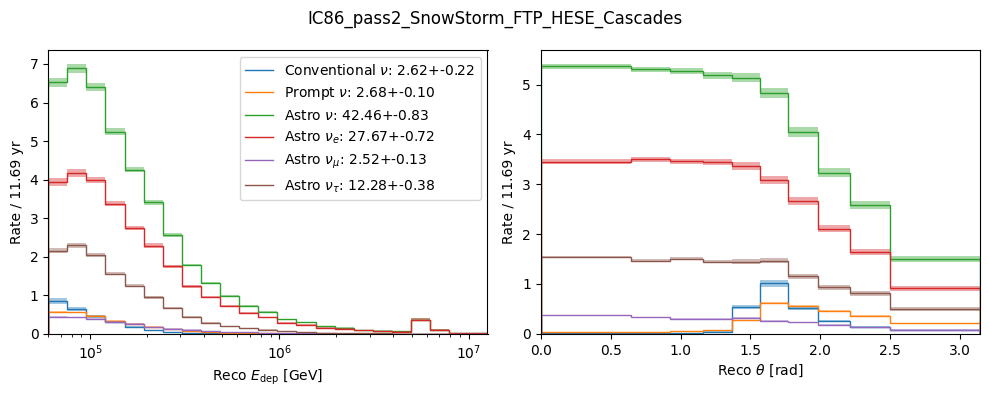

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


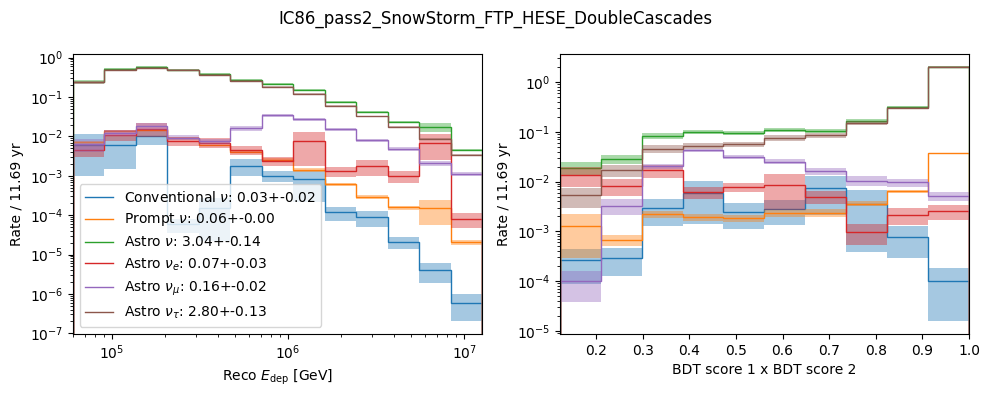

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


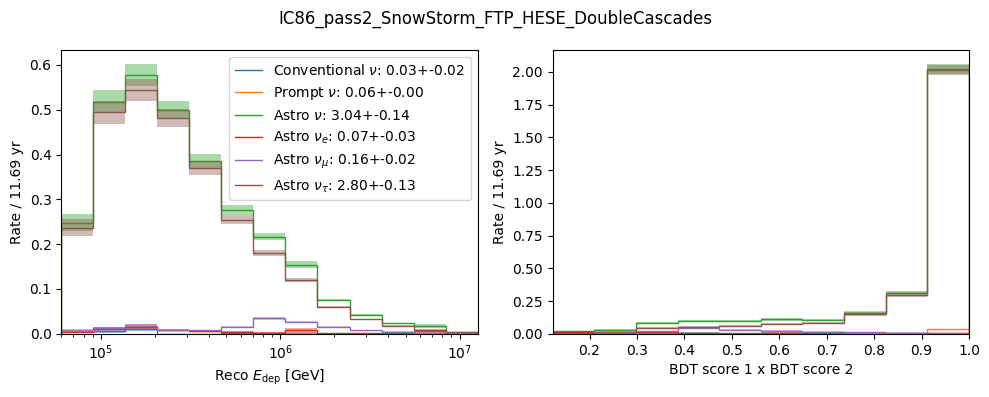

IC86_pass2_SnowStorm_FTP_HESE_Tracks


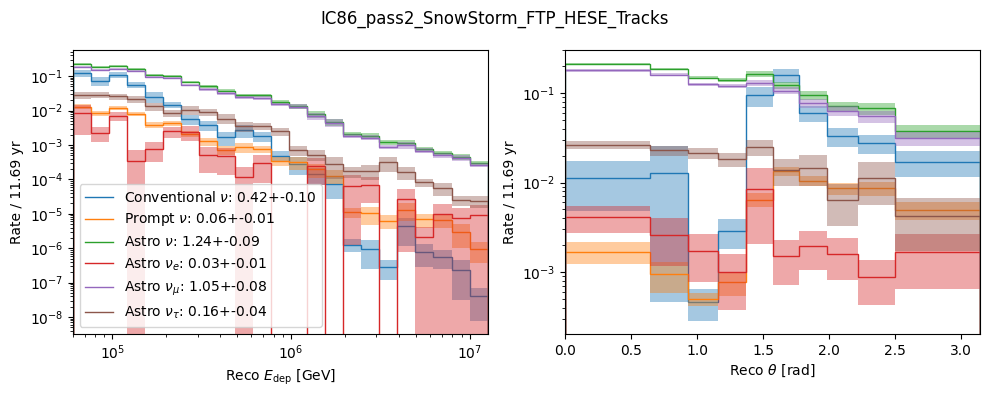

IC86_pass2_SnowStorm_FTP_HESE_Tracks


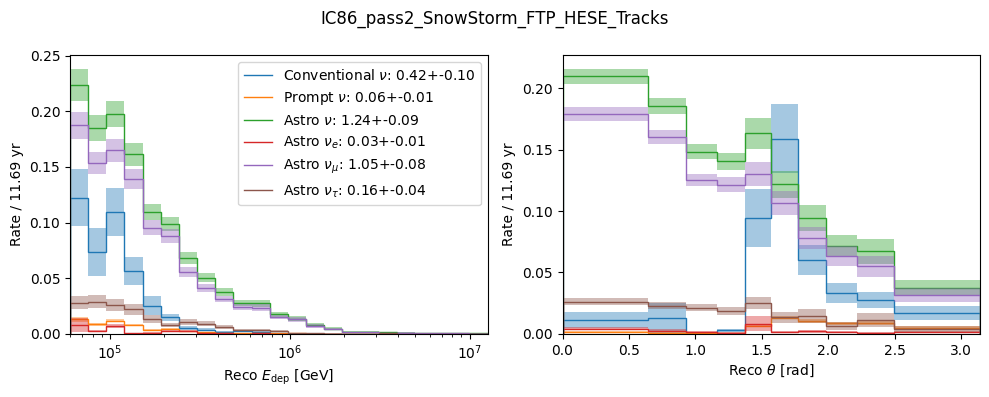

In [24]:
plotting_path_histogram = f"{plotting_path}/globalfit_hese_overlap"
os.system(f"mkdir -p {plotting_path_histogram}")

input_variables = {
    r"Conventional $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39,"a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0},
    r"Prompt $\nu$" : {"total_astro_norm" : 0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0},
    # r"Atmospherc $\mu$" : {"total_astro_norm" : 0.0, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1},
    r"Astro $\nu$" : {"total_astro_norm" : 3*1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_e$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\mu$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    r"Astro $\nu_\tau$" : {"total_astro_norm" : 1.77, "gamma_1" : 1.31, "gamma_2" : 2.74, "e_break" : 4.39, "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
}

for det_config in detector_configs: 
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=True, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-True.png")
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=False, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-False.png")